In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from typing import List, Optional, Union

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from src.visualization_helper import plot_grid_search_heatmap_from_csv, plot_feature_importances, plot_custom_confusion_matrix, plot_custom_roc_curve

In [2]:
# 1. Load the exported models and data
full_grid_search = joblib.load("../models/full_grid_search.pkl")
best_rf_model = joblib.load("../models/best_rf_model.pkl")

# Load the full results DataFrame for the heatmap
results_df = pd.read_csv("../models/grid_search_all_results.csv")


In [3]:
# Load the test sets
X_test = pd.read_csv("../data/processed/features_test.csv", index_col='id')
y_test = pd.read_csv("../data/processed/target_test.csv", index_col='id')['target']


In [3]:
# 2. Extract best parameters
best_parameters = full_grid_search.best_params_

In [4]:
best_parameters

{'class_weight': 'balanced',
 'max_depth': 7,
 'max_features': 'sqrt',
 'min_samples_leaf': 50,
 'n_estimators': 150}


--- Generating Grid Search Heatmap ---


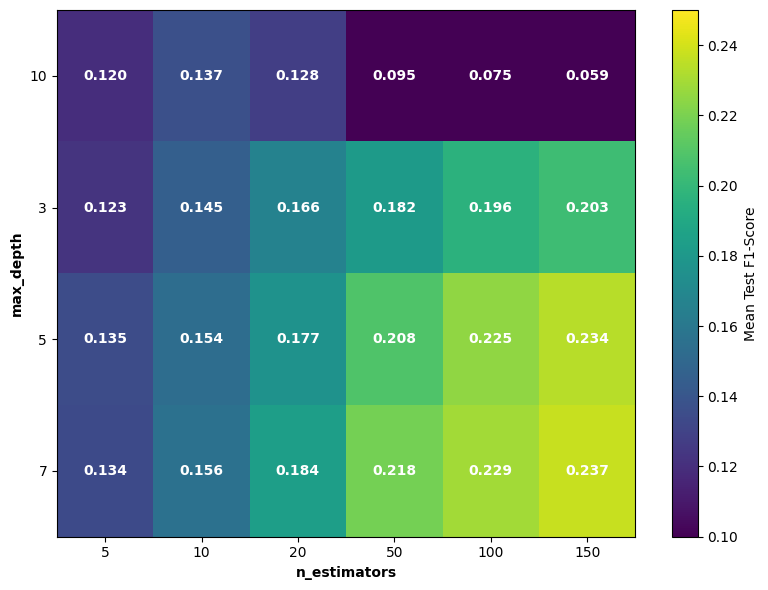

In [5]:
# 3. Plot the Heatmap
plot_grid_search_heatmap_from_csv(results_df, best_params=best_parameters)



--- Generating Top 20 Feature Importances ---


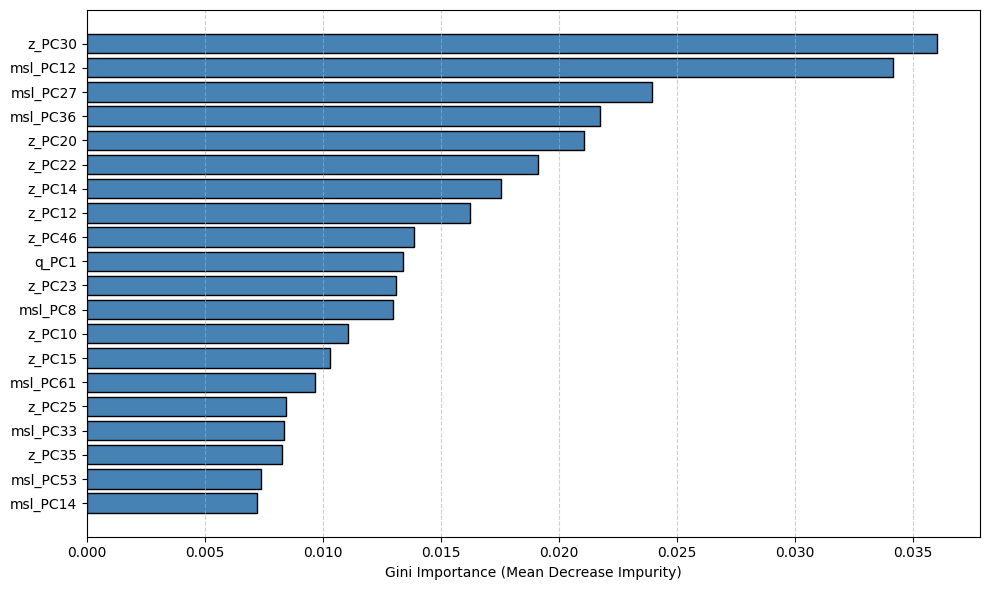

In [6]:
# 4. Plot Feature Importances
feature_cols = [col for col in X_test.columns if col != 'forecast_time']
plot_feature_importances(best_rf_model, feature_names=feature_cols, top_n=20)


In [7]:
# 5. Make predictions and Plot Confusion Matrix
y_pred = best_rf_model.predict(X_test[feature_cols])


--- Generating Confusion Matrix ---


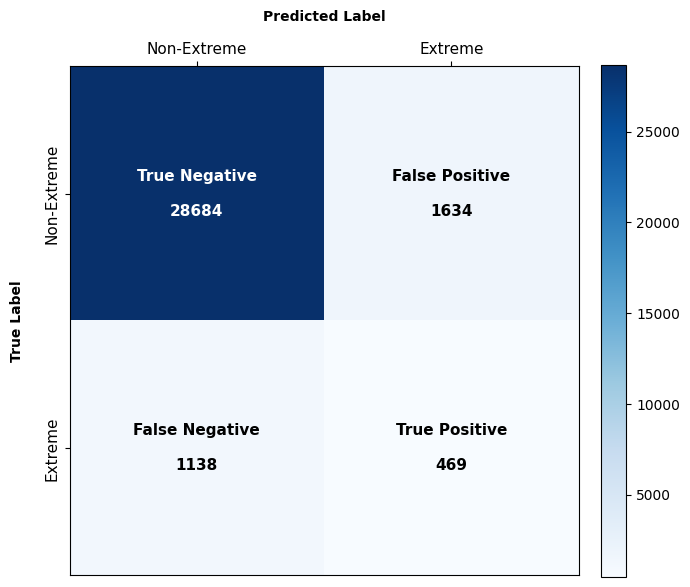

In [8]:
plot_custom_confusion_matrix(
    y_true=y_test, 
    y_pred=y_pred, 
    classes=['Non-Extreme', 'Extreme']
)


--- Generating ROC Curve ---


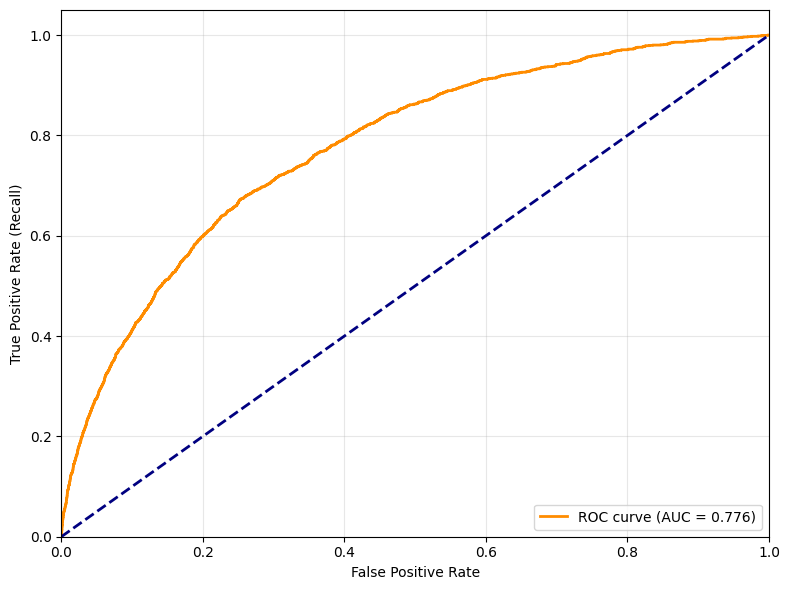

In [9]:

y_pred_probabilities = best_rf_model.predict_proba(X_test[feature_cols])[:, 1]

plot_custom_roc_curve(
    y_true=y_test, 
    y_prob=y_pred_probabilities
)

In [5]:
best_model_results = pd.read_csv("reports/final_model_metrics.csv")
best_model_results

,Set_Valutazione,F1_Score,AUC_ROC
0,Training (CV Mean),0.6031,0.9608
1,Validation (CV Mean),0.2375,0.7654
2,Test Set,0.2528,0.7762
